In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("diabetes.csv")
print(df.head())
print(df.isnull().sum())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
(768, 9)


In [ ]:
suspicious = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[suspicious] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
for col in suspicious:
  df[col]=df[col].replace(0,df[col].median())
print((df[suspicious] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [ ]:
x=df.drop(columns=['Outcome'])
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [ ]:
print(x_train.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   614.000000  614.000000     614.000000     614.000000  614.000000   
mean      3.742671  121.807818      72.229642      26.991857   95.843648   
std       3.313264   30.105181      12.099278       8.782951  106.736205   
min       0.000000   44.000000      24.000000       8.000000   14.000000   
25%       1.000000  100.000000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   42.500000   
75%       6.000000  139.000000      80.000000      32.000000  129.750000   
max      17.000000  199.000000     122.000000      63.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  614.000000                614.000000  614.000000  
mean    32.348208                  0.469168   32.907166  
std      6.935618                  0.336847   11.503437  
min     18.200000                  0.078000   21.000000  
25%     27.325000        

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled[:5])

[[-0.52639686 -1.25688146 -0.01899526 -0.45487119 -0.61269674 -0.05024677
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.32605067  0.8081742  -0.34092141 -0.61269674 -0.59858988
   2.41502991  1.48710085]
 [-0.82846011  0.57153617 -2.16963585 -0.91067031 -0.12042886 -0.52643947
   0.54916055 -0.94893896]
 [-1.13052335  1.30290323 -1.83876807 -0.45487119 -0.61269674 -1.50768503
  -0.63929127  2.79212217]
 [ 0.68185612  0.40531639  0.64274031  1.14042573  2.57063552  1.99882486
  -0.68682934  1.13909516]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred))

0.7532467532467533


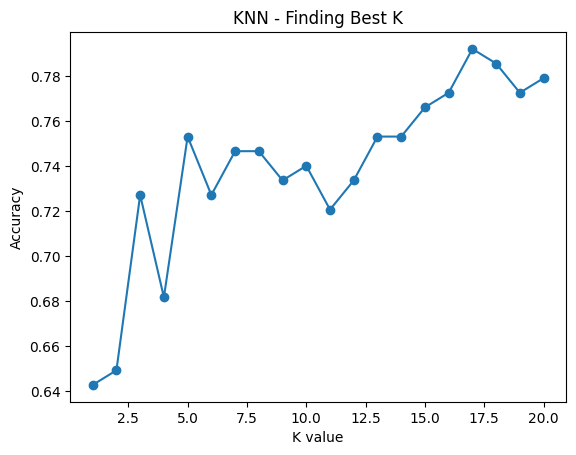

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred_k = knn.predict(x_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN - Finding Best K')
plt.show()

In [ ]:
best_k = k_values[accuracies.index(max(accuracies))]
print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 17
Best Accuracy: 0.7922077922077922


In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=17)
knn_final.fit(x_train_scaled, y_train)
y_pred_final = knn_final.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[88 11]
 [21 34]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        99
           1       0.76      0.62      0.68        55

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



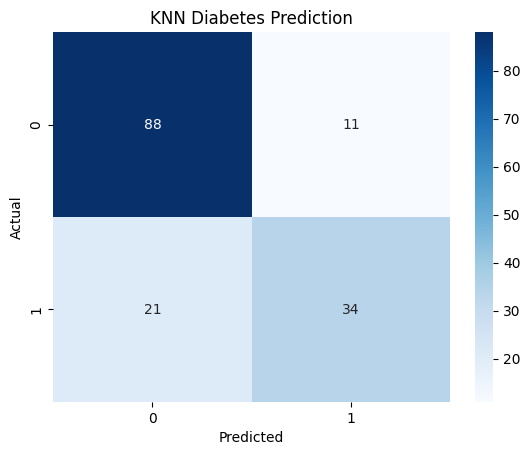

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, y_pred_final),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Diabetes Prediction')
plt.show()